# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;"> Project | Rain Forecasting</p>

<div style="border-radius:10px; padding: 15px; background-color: #FFDAB9; font-size:120%; text-align:left">

<h3 align="left"><font color=purple>Problem:</font></h3>

In this project, we delve into a dataset encapsulating various year, months rainfall and total rainfall to provided, it can be understood rainfall stratergy are useful for a rain forecasting. Accurate rainfall forecasts are essential for planning water allocation, storage, and distribution strategies. 
          It is crucial for their operations, to plan water allocation strategies and reservoir management more effectively.
          The goal of this project is to develop a machine learning model to forecast rainfall for upcoming months in Mumbai, India. By anticipating              rainfall patterns, they can optimize their operations and minimize costs while ensuring a consistent water supply throughout the year

<div style="border-radius:10px; padding: 15px; background-color: #FFDAB9; font-size:115%; text-align:left">

<h3 align="left"><font color=purple>Objectives:</font></h3>

* __Explore the Dataset__: Uncover patterns, distributions, and relationships within the data.
* __Conduct Extensive Exploratory Data Analysis (EDA)__: Dive deep into  relationships against the target.
* __Preprocessing Steps__:
  - Remove irrelevant featurs
  - Address missing values
* __Model Building__:
  - Implement and tune regressor models including Linear Regression, Random Forest Regressor, gradient Boosting Regressor and LSTM
* __Evaluate and Compare Model Performance__: Utilize MAE, MSE, RMSE, and R2-score to gauge models effectiveness.

<a id="contents_tabel"></a>    
<div style="border-radius:10px; padding: 15px; background-color: #FFDAB9; font-size:115%; text-align:left">

<h3 align="left"><font color=purple>Table of Contents:</font></h3>
    
* [Step 1 | Import Libraries](#import)
* [Step 2 | Read Dataset](#read)
* [Step 3 | Dataset Overview](#overview)
    - [Step 3.1 | Dataset Basic Information](#basic)
    - [Step 3.2 | Summary Statistics for Feature](#cat_statistics)
* [Step 4 | Data Preprocessing](#preprocessing)
    - [Step 4.1 | Irrelevant Features Removal](#featur_removal)
    - [Step 4.2 | Missing Value Treatment](#missing)
* [Step 5 | EDA](#eda)
* [Step 6 | Feature Engineering](#preprocessing)
* [Step 7 | Linear Regression Model Building](#logistic)
    - [Step 7.1 | Linear Base Model ](#logistic_base)
    - [Step 7.2 | Linear Regression Model Evaluation](#logistic_eval) 
* [Step 8 | Random Forest Regressor Model Building](#rf)
    - [Step 8.1 | RF Base Model Definition](#rf_base)
    - [Step 8.2 | RF Hyperparameter Tuning](#rf_hp)
    - [Step 8.3 | RF Model Evaluation](#rf_eval)
* [Step 9 | Gradient Boosting Regressor Model Building](#rf)
    - [Step 9.1 | GB Base Model ](#rf_base)
    - [Step 9.2 | GB Hyperparameter Tuning](#rf_hp)
    - [Step 9.3 | GB Model Evaluation](#rf_eval)
* [Step 10 | LSTM Model Building](#rf)
    - [Step 10.1 | Prepare Data For LSTM ](#rf_base)
    - [Step 10.2 | Build LSTM Model](#rf_hp)
    - [Step 10.3 | Train LSTM Model](#rf_eval)
    - [Step 10.4 | LSTM Prediction](#rf_hp)
    - [Step 10.5 | Evaluation Function](#rf_eval)
* [Step 11 | Model Comparision Summary](#conclusion)
* [Step 12 | Feature Importance(GB Model)](#conclusion)
* [Step 13 | Visualization of prediction](#conclusion)
* [Step 14 | Conclusion](#conclusion)

<a id="import"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>

⬆️ [Table of Contents](#contents_tabel)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import joblib

from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge,Lasso

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set the resolution of the plotted figure
plt.rcParams['figure.dpi'] = 100

# Configure seaborn plot styles: Set background color and use dark grid
sns.set(rc ={'axes.facecolor': '#faded9'}, style='darkgrid')

In [3]:
pio.templates["custom"] = dict(
    layout=dict(
        plot_bgcolor="#faded9",
        paper_bgcolor="#faded9",
        font=dict(color="black"),
        xaxis=dict(showgrid=True,gridcolor="gray"),
        yaxis=dict(showgrid=True, gridcolor="gray")     
    )
)
pio.templates.default= "custom"

<a id="read"></a>
# <p style="background-color:purple ; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read Dataset</p>

⬆️ [Table of Contents](#contents_tabel)

In [4]:
df = pd.read_csv(r"C:\Users\HP\Downloads\mumbai-monthly-rains.csv")

In [5]:
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    121 non-null    int64  
 1   Jan     121 non-null    float64
 2   Feb     121 non-null    float64
 3   Mar     121 non-null    float64
 4   April   121 non-null    float64
 5   May     121 non-null    float64
 6   June    121 non-null    float64
 7   July    121 non-null    float64
 8   Aug     121 non-null    float64
 9   Sept    121 non-null    float64
 10  Oct     121 non-null    float64
 11  Nov     121 non-null    float64
 12  Dec     121 non-null    float64
 13  Total   121 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 13.4 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,121.0,1961.000000,35.073732,1901.000000,1931.000000,1961.000000,1991.000000,2021.000000
Jan,121.0,1.567235,6.462247,0.000000,0.000000,0.000000,0.000000,51.348290
Feb,121.0,0.929358,3.077050,0.000000,0.000000,0.000000,0.152298,21.107118
Mar,121.0,0.869231,2.890032,0.000000,0.000000,0.000000,0.000000,18.252996
April,121.0,1.428458,7.371307,0.000000,0.000000,0.000000,0.194165,75.541818
May,121.0,18.183632,48.628812,0.000000,0.000000,0.355001,4.208322,234.392757
June,121.0,517.854402,251.067016,61.058662,324.094617,482.449872,678.040770,1219.518576
July,121.0,757.407412,285.836188,103.209194,540.745923,788.403637,942.616099,1358.833554
Aug,121.0,465.600818,249.072915,87.493370,268.002392,445.870342,604.372615,1200.956558
Sept,121.0,312.885747,205.135368,36.313545,149.584208,269.276549,398.645218,987.796660


<a id="overview"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Dataset Overview</p>

⬆️ [Table of Contents](#contents_tabel)

<a id="basic"></a>
# <b><span style='color:#4B0082'>Step 3.1 |</span><span style='color:purple'> Dataset Basic Information</span></b>

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    121 non-null    int64  
 1   Jan     121 non-null    float64
 2   Feb     121 non-null    float64
 3   Mar     121 non-null    float64
 4   April   121 non-null    float64
 5   May     121 non-null    float64
 6   June    121 non-null    float64
 7   July    121 non-null    float64
 8   Aug     121 non-null    float64
 9   Sept    121 non-null    float64
 10  Oct     121 non-null    float64
 11  Nov     121 non-null    float64
 12  Dec     121 non-null    float64
 13  Total   121 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 13.4 KB


<div style="border-radius:10px; padding: 15px; background-color: #FFDAB9; font-size:115%; text-align:left">

<h2 align="left"><font color= purple>Inferences:</font></h2>

* __Number of Entries__: The dataset consists of __121 entries__, ranging from index 0 to 120.
    
    
* __Columns__: There are __14 columns__ in the dataset corresponding to various attributes regarding to rain forcasting.
    
    
* __Data Types__:
    -  __1__Columns are of the __int64__ data type.
    - __13__Columns are of the __float64__ data type. 
    
    
* __Missing Values__: There don't appear to be any missing values in the dataset as each column has 121 non-null entries.

<a id="num_statistics"></a>
# <b><span style='color:#4B0082'>Step 3.2 |</span><span style='color:purple'> Summary Statistics for features</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #FFDAB9; font-size:115%; text-align:left">

<h3 align="left"><font color=purple> Features:</font></h3>

* __`Year`__: The average rainfall in year 1961, with the maximum in 2021 and the minimum rainfall in year 1901.
* __`Jan`__: The average rainfall in month is approximately 1.56 mm , Maximum is 51.34 mm  and Minimum is 0.00 mm
* __`Feb`__: The average rainfall in month is approximately 0.92 mm , Maximum is 21.10 mm  and Minimum is 0.00 mm
* __`Mar`__: The average rainfall in month is approximately 0.86 mm , Maximum is 18.25 mm  and Minimum is 0.00 mm
* __`April`__: The average rainfall in month is approximately 1.42 mm , Maximum is 75.54 mm  and Minimum is 0.00 mm
* __`May`__:The average rainfall in month is approximately 18.18 mm , Maximum is 234.39 mm  and Minimum is 0.00 mm 
* __`Jun`__: The average rainfall in month is approximately 517.85 mm , Maximum is 1219.91 mm  and Minimum is 61.05 mm
* __`July`__: The average rainfall in month is approximately 757.40 mm , Maximum is 1358.83 mm  and Minimum is 103.20 mm
* __`Aug`__: The average rainfall in month is approximately 465.60 mm , Maximum is 1200 mm  and Minimum is 87.49 mm
* __`Sept`__:The average rainfall in month is approximately 312.88 mm , Maximum is 987.79 mm  and Minimum is 36.31 mm 
* __`Oct`__:The average rainfall in month is approximately 73.98 mm , Maximum is 552.90 mm  and Minimum is 0.00 mm 
* __`Nov`__: The average rainfall in month is approximately 13.84 mm , Maximum is 164.34 mm  and Minimum is 0.00 mm
* __`Dec`__: The average rainfall in month is approximately 3.55 mm , Maximum is 90.04 mm  and Minimum is 0.00 mm
* __`Total`__: The average rainfall all year approximately 2168.11 mm , Maximum is 3563.25 mm  and Minimum is 1058.84 mm

<a id="preprocessing"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | Data Preprocessing</p>

⬆️ [Table of Contents](#contents_tabel)

____
<a id="missing"></a>
# <b><span style='color:#4B0082'>Step 4.1 |</span><span style='color:purple'> Missing Value Treatment</span></b>

In [9]:
df.isnull().sum()

Year     0
Jan      0
Feb      0
Mar      0
April    0
May      0
June     0
July     0
Aug      0
Sept     0
Oct      0
Nov      0
Dec      0
Total    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

<div style="border-radius:10px; padding: 15px; background-color: #FFDAB9; font-size:115%; text-align:left">
    
Upon our above inspection, it is obvious that there are no missing values and no duplicate in our dataset. This is ideal as it means we don't have to make decisions about imputation or removal.

<a id="eda"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 5 | EDA</p>

⬆️ [Table of Contents](#contents_tabel)

## Exploratory Data Analysis (EDA)

### Total Rainfall Trend By Year

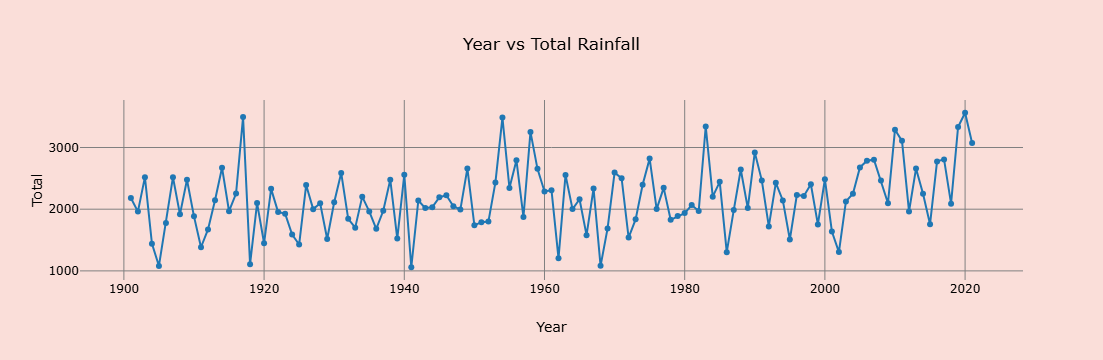

In [11]:
fig = px.line(
    df,
    x = 'Year',
    y = 'Total',
    title = 'Year vs Total Rainfall',
    markers = True
)

fig.show()

### Monthly Average Rainfall

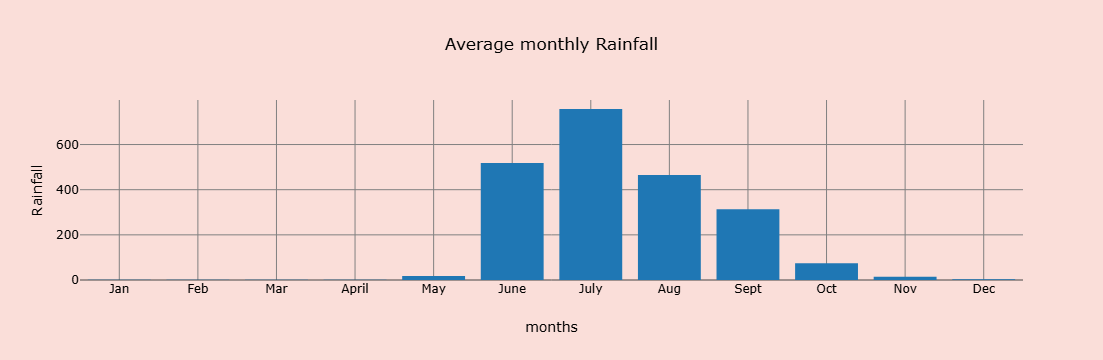

In [12]:
monthly_avg = df.iloc[:,1:13].mean()

fig = px.bar(
    x = monthly_avg.index,
    y = monthly_avg.values,
    labels = {'x':'months','y':'Rainfall'},
    title = 'Average monthly Rainfall'
)
fig.show()

### Rainfall Distribution

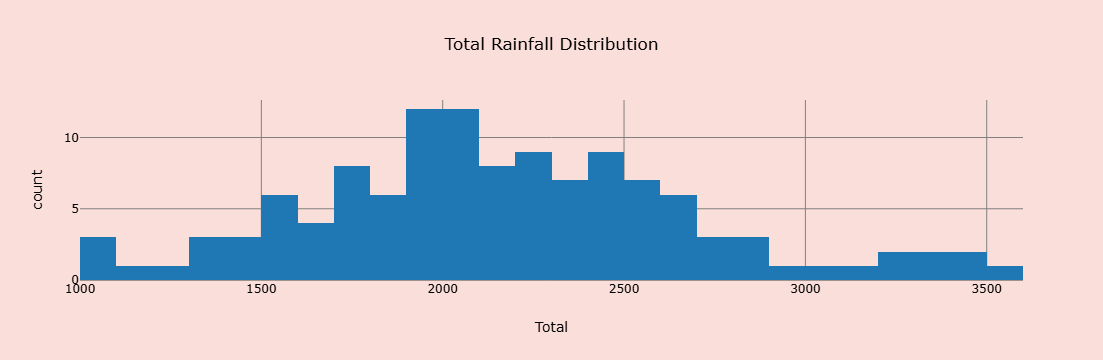

In [13]:
fig = px.histogram(
    df,
    x = 'Total',
    nbins = 30,
    title = 'Total Rainfall Distribution'
)

fig.show()

### Box Plot For Outlier Detection

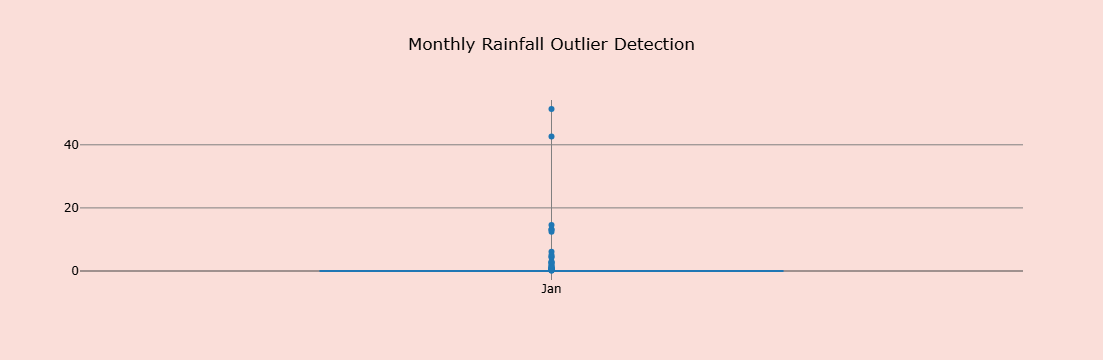

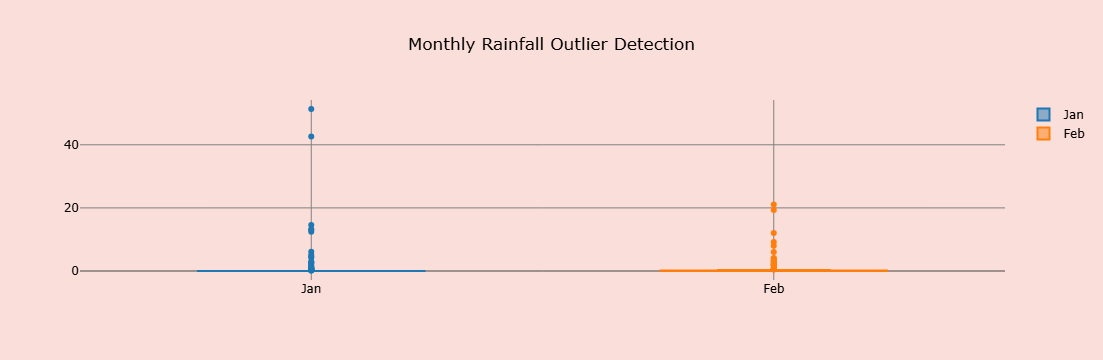

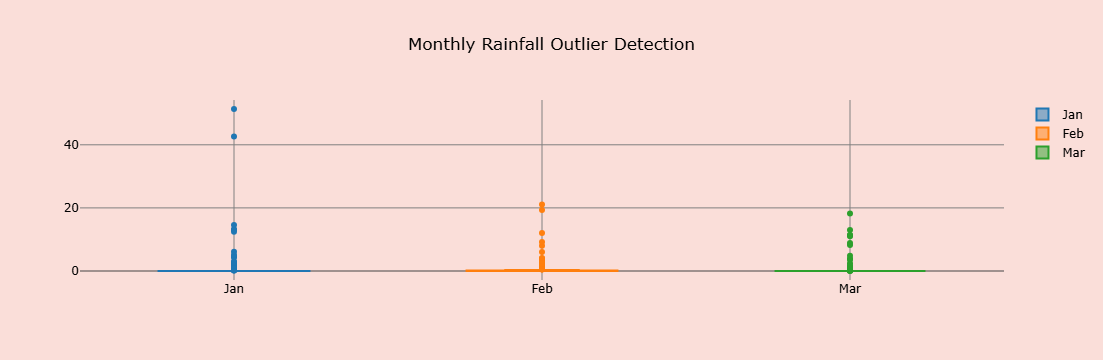

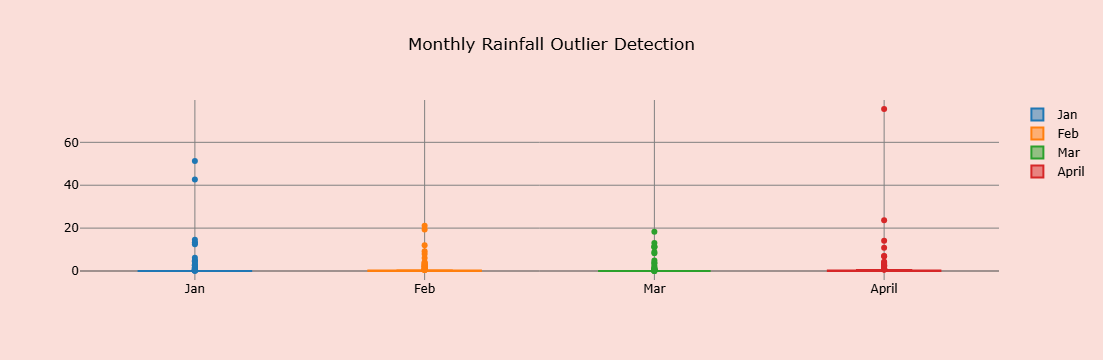

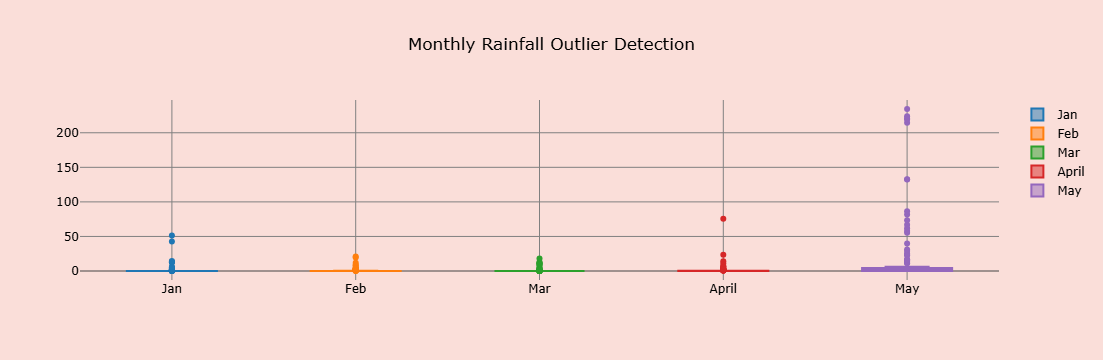

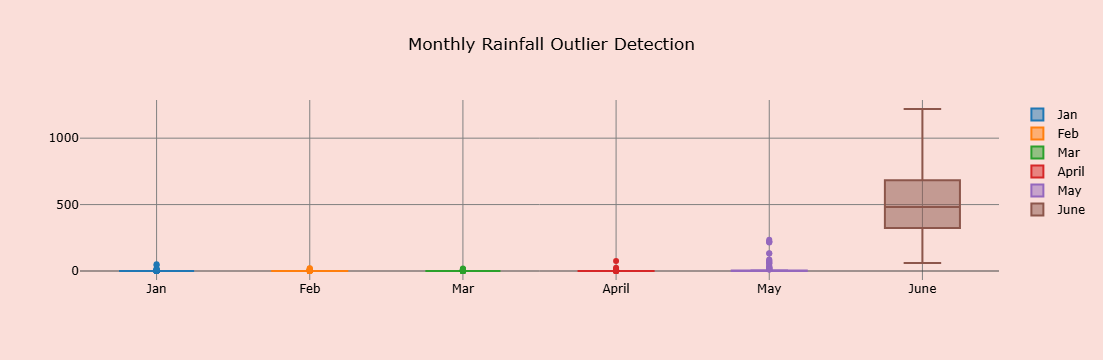

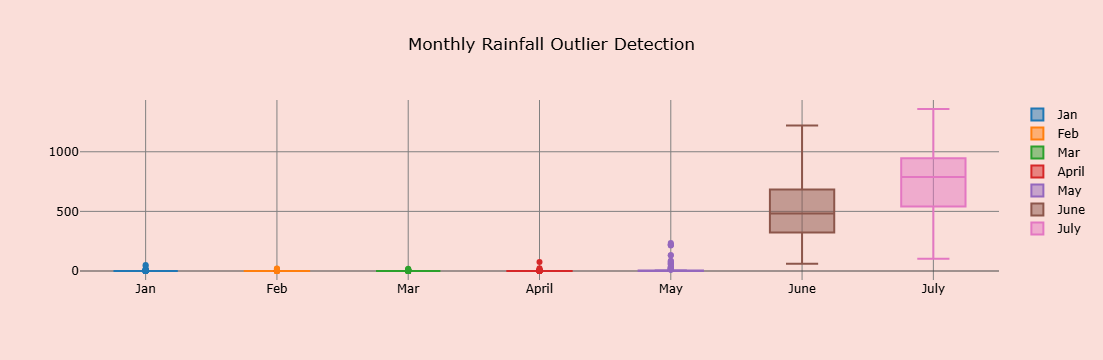

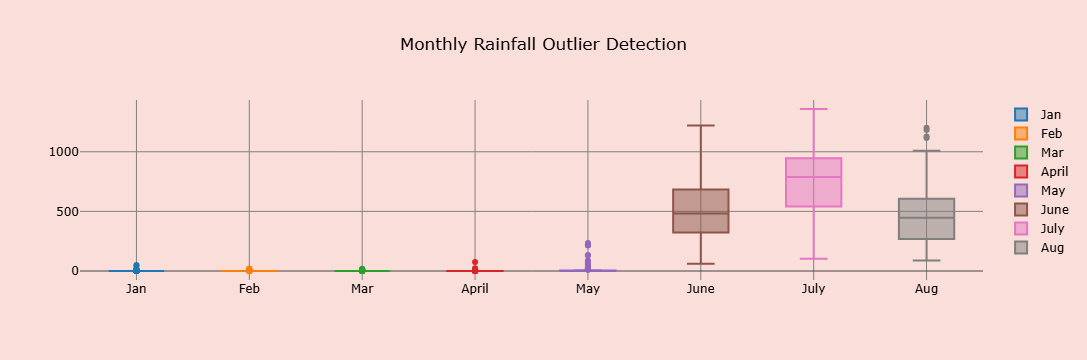

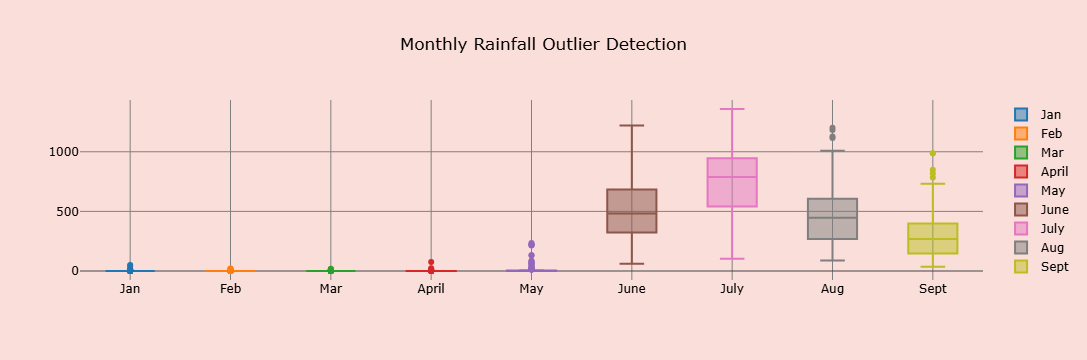

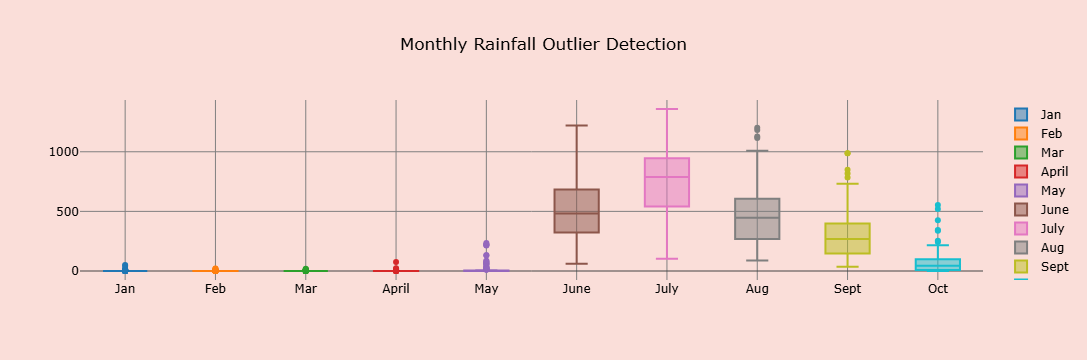

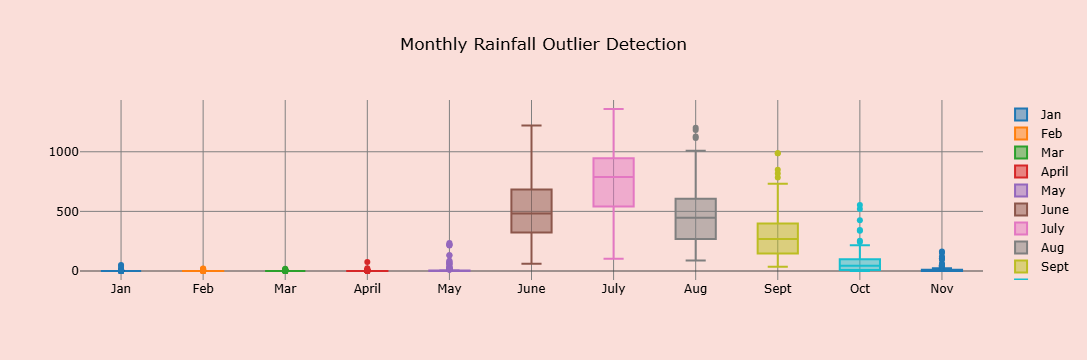

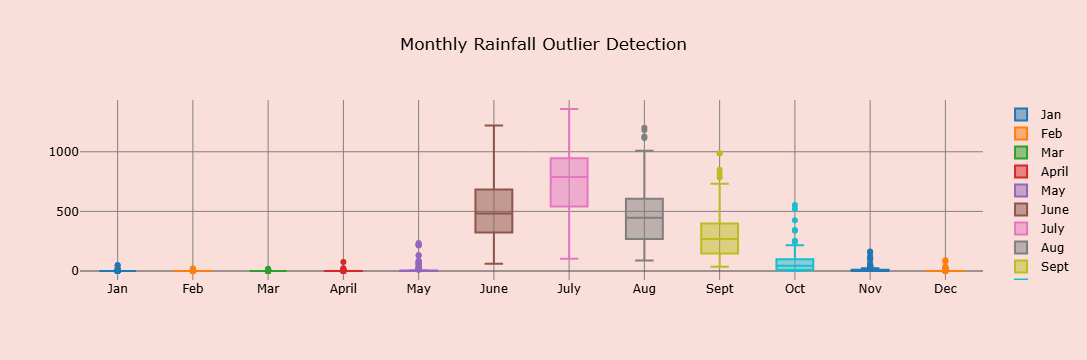

In [14]:
months = df.columns[1:13]

fig = go.Figure()

for month in months:
    fig.add_trace(go.Box(
        y = df[month],
        name = month
    ))
    fig.update_layout(
        title = 'Monthly Rainfall Outlier Detection'
    )
    fig.show()

### Monthly Rainfall Trend

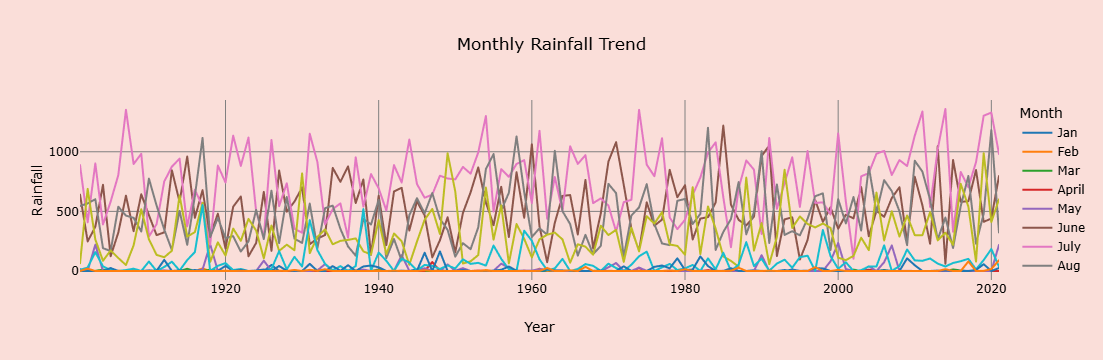

In [15]:
df_melt = df.melt(
    id_vars=['Year'],
    value_vars=df.columns[1:13],
    var_name='Month',
    value_name='Rainfall'
)
fig=px.line(
     df_melt,
     x='Year',
     y= 'Rainfall',
     color='Month',
     title='Monthly Rainfall Trend' 
 )
fig.show()

### Year vs Total Rainfall

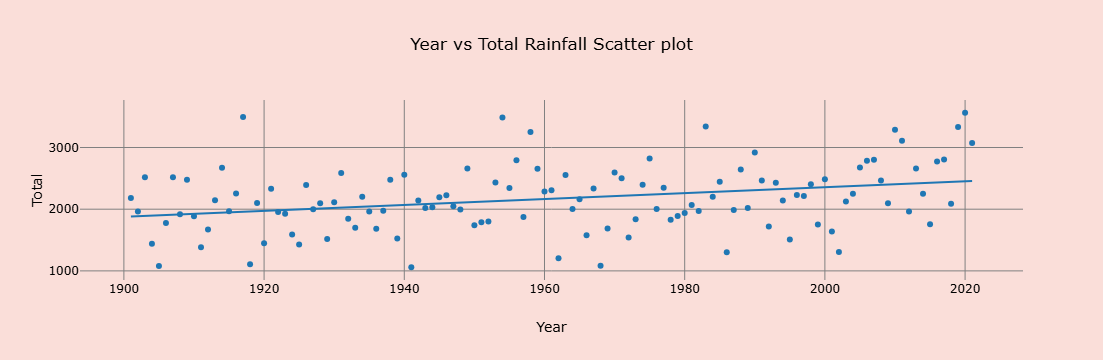

In [16]:
fig=px.scatter(
     df,
     x='Year',
     y='Total',
    trendline='ols',
     title = 'Year vs Total Rainfall Scatter plot')
fig.show()

### Monthly Rainfall Contribution

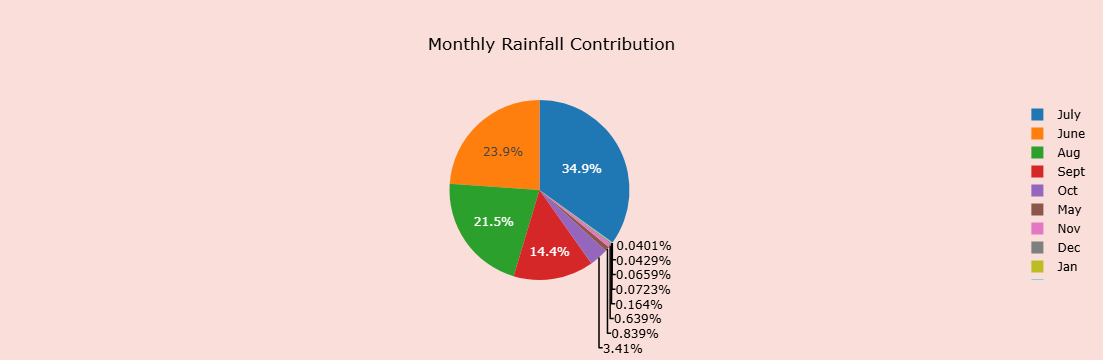

In [17]:
monthly_avg = df.iloc[:,1:13].mean()

fig = px.pie(
    names = monthly_avg.index,
    values = monthly_avg.values,
    title = 'Monthly Rainfall Contribution'
)
fig.show()

### Feature Correlation Heatmap

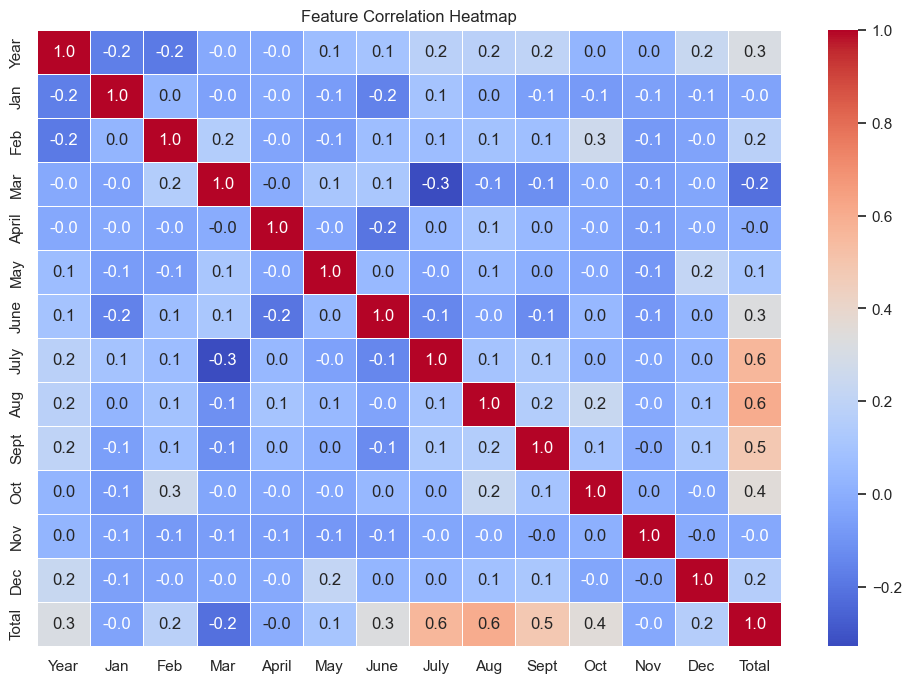

In [18]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".1f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Heatmap of Monthly Rainfall

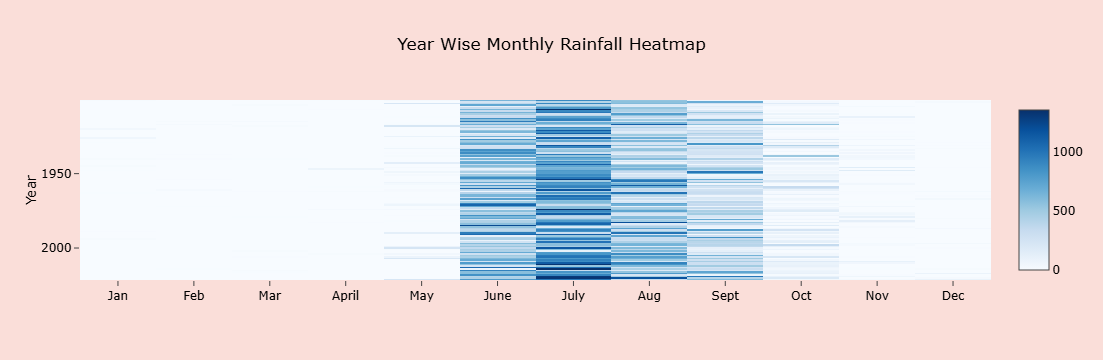

In [19]:
fig = px.imshow(
    df.set_index('Year').iloc[:,0:12],
    aspect = 'auto',
    color_continuous_scale='Blues',
    title = 'Year Wise Monthly Rainfall Heatmap'
)

fig.show()

<div style="border-radius:10px; padding: 15px; background-color: #FFDAB9; font-size:115%; text-align:left">

<h2 align="left"><font color=purple>Inferences:</font></h2>

* __Year vs Total Rainfall__: Total rainfall for each year. x_axis shows year(from 1901 to 2021),
                              y_axis show Total rainfall(Rainfall amount).
                              The rainfall is not constant every year. It goes up and down from year to year
                              Some year have very high rainfall- Approximate high rainfall period:-
                                                                    Around 1918-1920
                                                                    Around 1953-1960
                                                                    Around 1982-1985
                                                                    Around 2005-2010
                                                                    Around 2018-2021

  In this year rainfall reached around 3000-3500+ and some year show low rainfall period:-
                                                                                       Around-1905,1919,1940,1965-1968,1983,2000 These year have rainfall near 1000-1500.
                  
* __Monthly Average Rainfall__: x_axis shows months(Jan to Dec) and y_axis shows Average rainfall amount.
                                Months from Jan to April show almost zero rainfall. These months show winter/summer season.
                                In may ,rainfall start increasing slightly. This indicates pre-monsoon rainfall start.
                                The highest rainfall occurs from June to September. In June 500+ mm rainfall indicates,
                                chart show July is highest rainfall month in year approximate 700-750 mm,
                                In August rainfall remains high. Slightly lower than July around 450-500 mm,
                                In September decreases gradually. Monsoon start reducing 300-350 mm rainfall.
                                Rainfall decreases after monsoon. In October around 100 mm rainfall and November, December show almost no rainfall
                  
    
    
* __Total Rainfall Distribution__: x-axis represent total rainfall values around(1000 to 3500) and 
                                   y_axis represent Frequency means number of times raifall value appear.
                                   Most rainfall values are between 1800-2600.
                                   Very low and very high rainfall year are rare.
                                   Dataset looks reasonably balanced.
                                   Possible outliers exit but may be natural.
                                   Data is good for regression model training.
    
    
* __Monthly Rainfall Outlier Detection__: July has highest rainfall.
                                           Jan-Mar and Nov-Dec dry months
                                            Monsoon months have high variation
                                            Some rainfall outliers exist
                                            Most outliers are probably real weather events,not errors
                        
    
    
* __Monthly Rainfall Trend__: This chart shows the monthly rainfall trend over many years (around 1901-2021) for diffrent months(Jan-Dec)
                              x-axis represent year and, y_axis represent rainfall amount.
                              Some Months have very high rainfall(likely June,July,Aug,Sept).
                              This suggests monsoon months receive maximum rainfall and non-monsoon months receive less rainfall
                           

* __Monthly Rainfall Contribution__: In pie chart shows which month contributes how much percentage of total rainfall in dataset
                                     Rainfall is highly seasonal and concentrated in monsoon months.
                                     July contributes the highest rainfall(~34.9%), followed by June (~23.9%) and August(~21.5%).
                                     Winter and post-monsoon months contribute very little rainfall,
                                     Indicating a strong seasonal rainfall pattern in the dataset
                           

* __Feature Correlation Heatmap__: The feature correlation heatmap indicates that annual rainfall is strongly associated with monsoon months,
                                   particularly July and August ,which show the highest positive correlation with total rainfall.
                                   Most other monthly features exhibits weak correlations, indicating a complex and non-linear rainfall pattern.
                      

<a id="preprocessing"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 6 | Feature Engineering</p>

⬆️ [Table of Contents](#contents_tabel)

### Create Seasonal Features

In [20]:
# Winter Rainfall
df['Winter_Rainfall'] = df['Jan'] + df['Feb']

# Summer Rainfall
df['Summer_Rainfall'] = df['Mar'] + df['April'] + df['May']

#Monsoon rainfall
df['Monsoon_Rainfall'] =( df['June'] + df['July'] + df['Aug'] + df['Sept'])

# Post-Monsoon Rainfall
df['PostMonsoon_Rainfall'] = (df['Oct'] + df['Nov'] + df['Dec'])

df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total,Winter_Rainfall,Summer_Rainfall,Monsoon_Rainfall,PostMonsoon_Rainfall
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796,13.116602,21.089460,2138.401038,9.871696
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334,0.000000,0.355001,1911.941830,48.669504
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240,0.000000,221.412775,2140.307588,157.892877
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168,0.000000,11.381769,1391.255450,38.679948
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250,2.376012,0.000000,1045.378739,32.269499


## Rainfall Statistics

### Average Monthly Rainfall Feature

In [21]:
df['avg_Rainfall'] = df.iloc[:,1:13].mean(axis=1)
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total,Winter_Rainfall,Summer_Rainfall,Monsoon_Rainfall,PostMonsoon_Rainfall,avg_Rainfall
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796,13.116602,21.089460,2138.401038,9.871696,181.873233
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334,0.000000,0.355001,1911.941830,48.669504,163.413861
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240,0.000000,221.412775,2140.307588,157.892877,209.967770
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168,0.000000,11.381769,1391.255450,38.679948,120.109764
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250,2.376012,0.000000,1045.378739,32.269499,90.002021


### Maximum Rainfall Month Feature

In [22]:
df['Max_Rainfall'] = df.iloc[:,1:13].max(axis=1)
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total,Winter_Rainfall,Summer_Rainfall,Monsoon_Rainfall,PostMonsoon_Rainfall,avg_Rainfall,Max_Rainfall
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796,13.116602,21.089460,2138.401038,9.871696,181.873233,888.369692
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334,0.000000,0.355001,1911.941830,48.669504,163.413861,688.913455
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240,0.000000,221.412775,2140.307588,157.892877,209.967770,902.447896
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168,0.000000,11.381769,1391.255450,38.679948,120.109764,723.081969
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250,2.376012,0.000000,1045.378739,32.269499,90.002021,581.827975


### Minimum Rainfall Feature

In [23]:
df['Min_Rainfall'] = df.iloc[:,1:13].min(axis=1)
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,...,Nov,Dec,Total,Winter_Rainfall,Summer_Rainfall,Monsoon_Rainfall,PostMonsoon_Rainfall,avg_Rainfall,Max_Rainfall,Min_Rainfall
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,...,0.000000,0.000000,2182.478796,13.116602,21.089460,2138.401038,9.871696,181.873233,888.369692,0.0
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,...,0.488864,19.526547,1960.966334,0.000000,0.355001,1911.941830,48.669504,163.413861,688.913455,0.0
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,...,0.000000,0.000000,2519.613240,0.000000,221.412775,2140.307588,157.892877,209.967770,902.447896,0.0
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,...,0.000000,0.000000,1441.317168,0.000000,11.381769,1391.255450,38.679948,120.109764,723.081969,0.0
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,...,24.903575,0.000000,1080.024250,2.376012,0.000000,1045.378739,32.269499,90.002021,581.827975,0.0


### Rainfall Variability Feature

In [24]:
df['Rainfall_STD'] = df.iloc[:,1:13].std(axis=1)
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,...,Dec,Total,Winter_Rainfall,Summer_Rainfall,Monsoon_Rainfall,PostMonsoon_Rainfall,avg_Rainfall,Max_Rainfall,Min_Rainfall,Rainfall_STD
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,...,0.000000,2182.478796,13.116602,21.089460,2138.401038,9.871696,181.873233,888.369692,0.0,316.883306
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,...,19.526547,1960.966334,0.000000,0.355001,1911.941830,48.669504,163.413861,688.913455,0.0,253.109347
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,...,0.000000,2519.613240,0.000000,221.412775,2140.307588,157.892877,209.967770,902.447896,0.0,290.673781
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,...,0.000000,1441.317168,0.000000,11.381769,1391.255450,38.679948,120.109764,723.081969,0.0,223.240266
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,...,0.000000,1080.024250,2.376012,0.000000,1045.378739,32.269499,90.002021,581.827975,0.0,169.234784


### Lag Feature(Previous year Rainfall)

In [25]:
df['Previous_year_Total'] = df['Total'].shift(1)
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,...,Total,Winter_Rainfall,Summer_Rainfall,Monsoon_Rainfall,PostMonsoon_Rainfall,avg_Rainfall,Max_Rainfall,Min_Rainfall,Rainfall_STD,Previous_year_Total
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,...,2182.478796,13.116602,21.089460,2138.401038,9.871696,181.873233,888.369692,0.0,316.883306,NaN
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,...,1960.966334,0.000000,0.355001,1911.941830,48.669504,163.413861,688.913455,0.0,253.109347,2182.478796
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,...,2519.613240,0.000000,221.412775,2140.307588,157.892877,209.967770,902.447896,0.0,290.673781,1960.966334
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,...,1441.317168,0.000000,11.381769,1391.255450,38.679948,120.109764,723.081969,0.0,223.240266,2519.613240
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,...,1080.024250,2.376012,0.000000,1045.378739,32.269499,90.002021,581.827975,0.0,169.234784,1441.317168


In [26]:
df.fillna(0,inplace=True)

### Rolling Average Feature

In [27]:
df['Rolling_Mean_3Y'] = (
    df['Total'].rolling(window=3).mean()
)

df.fillna(0, inplace=True)

In [28]:
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,...,Winter_Rainfall,Summer_Rainfall,Monsoon_Rainfall,PostMonsoon_Rainfall,avg_Rainfall,Max_Rainfall,Min_Rainfall,Rainfall_STD,Previous_year_Total,Rolling_Mean_3Y
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,...,13.116602,21.089460,2138.401038,9.871696,181.873233,888.369692,0.0,316.883306,0.000000,0.000000
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,...,0.000000,0.355001,1911.941830,48.669504,163.413861,688.913455,0.0,253.109347,2182.478796,0.000000
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,...,0.000000,221.412775,2140.307588,157.892877,209.967770,902.447896,0.0,290.673781,1960.966334,2221.019457
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,...,0.000000,11.381769,1391.255450,38.679948,120.109764,723.081969,0.0,223.240266,2519.613240,1973.965581
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,...,2.376012,0.000000,1045.378739,32.269499,90.002021,581.827975,0.0,169.234784,1441.317168,1680.318219


In [29]:
# Rainfall Variability
df['Rainfall_Range'] = df['Max_Rainfall']-df['Min_Rainfall']

#Seational ratio
df['Monsoon_Ratio'] = (
    df['Monsoon_Rainfall'] / df['Total']
)
# Year tread
df['Year_squared'] = df['Year']**2

In [30]:
df['Previous_2_Year'] = df['Total'].shift(2)
df['Previous_3_Year'] = df['Total'].shift(3)

In [31]:
df.fillna(df.mean(), inplace=True)

In [32]:
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,...,Max_Rainfall,Min_Rainfall,Rainfall_STD,Previous_year_Total,Rolling_Mean_3Y,Rainfall_Range,Monsoon_Ratio,Year_squared,Previous_2_Year,Previous_3_Year
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,...,888.369692,0.0,316.883306,0.000000,0.000000,888.369692,0.979804,3613801,2148.781150,2138.744916
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,...,688.913455,0.0,253.109347,2182.478796,0.000000,688.913455,0.975000,3617604,2148.781150,2138.744916
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,...,902.447896,0.0,290.673781,1960.966334,2221.019457,902.447896,0.849459,3621409,2182.478796,2138.744916
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,...,723.081969,0.0,223.240266,2519.613240,1973.965581,723.081969,0.965267,3625216,1960.966334,2182.478796
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,...,581.827975,0.0,169.234784,1441.317168,1680.318219,581.827975,0.967922,3629025,2519.613240,1960.966334


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  121 non-null    int64  
 1   Jan                   121 non-null    float64
 2   Feb                   121 non-null    float64
 3   Mar                   121 non-null    float64
 4   April                 121 non-null    float64
 5   May                   121 non-null    float64
 6   June                  121 non-null    float64
 7   July                  121 non-null    float64
 8   Aug                   121 non-null    float64
 9   Sept                  121 non-null    float64
 10  Oct                   121 non-null    float64
 11  Nov                   121 non-null    float64
 12  Dec                   121 non-null    float64
 13  Total                 121 non-null    float64
 14  Winter_Rainfall       121 non-null    float64
 15  Summer_Rainfall       1

<div style="border-radius:10px; padding: 15px; background-color: #FFDAB9; font-size:115%; text-align:left">
    
Adding these columns is called feature engineering.In a rain forecasting dataset, these feature help the model understand rainfall patterns, seasonality,trends, variability and past behaviour. This can improve model accuracy.

<div style="border-radius:10px; padding: 15px; background-color: #FFDAB9; font-size:120%; text-align:left">

<h2 align="left"><font color=red>Dataset Description:</font></h2>
    
| __Variable__ | __Description__ |
|     :---      |       :---      | 
|__Year__| Year of rainfall data(1901-2021) |
| __Jan to Dec__ | Monthly rainfall amount for each month |
| __Total__ | Total rainfall of the whole year |
| __Winter_Rainfall__ | Rainfall during winter season |
| __Summer_Rainfall__ | Rainfall during summer season |
| __Monsoon_Rainfall__ | Rainfall during monsoon season |                     
| __Post_Monsoon_Rainfall__ | Rainfall during post-monsoon season |
| __Avg_Rainfall__| Average rainfall of the year |  
| __Max_Rainfall__ | Maximun monthly rainfall in that year|                      
| __Min_rainfall__ | Minimum monthly rainfall in that year |
| __Rainfall_STD__ | Standard deviation of rainfall(variation in rainfall) |
| __Previous_Year_Total__ | Total rainfall of previous year|                      
| __Rolling_Mean_3Year__ | Average rainfall of last 3 years |              
| __Rainfall_Range__ | Difference between maximun and minimum monthly rainfall in a year  |
| __Monsoon_Ratio__ | Percentage of annual rainfall coming from monsoon months |
|__Year_Squared__| Square of the year value to capture nonlinear trends over time|
|__Previous 2 Year_Rainfall__| Total rainfall value from 2 years before current year |
|__Previous 3 Year_Rainfall__| Total rainfall value from 3 years before current year |

### Feature and Target

In [34]:
features = ['Year','Jan','Feb','Mar','April','May','June','July','Aug','Sept','Oct','Nov','Dec',
            'Winter_Rainfall','Summer_Rainfall','Monsoon_Rainfall','PostMonsoon_Rainfall',
           'avg_Rainfall','Max_Rainfall','Min_Rainfall','Rainfall_STD','Previous_year_Total',
           'Rolling_Mean_3Y','Rainfall_Range','Monsoon_Ratio','Year_squared','Previous_2_Year','Previous_3_Year']

target='Total'

x=df[features]
y=df[target]

### Split Data

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state =42)

In [36]:
x_train.shape, y_train.shape

((96, 28), (96,))

In [37]:
x_test.shape, y_test.shape

((25, 28), (25,))

<a id="logistic"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 7 | Linear Regression Model Building</p>

⬆️ [Table of Contents](#contents_tabel)

____
<a id="logistic_base"></a>
# <b><span style='color:#4B0082'>Step 7.1 |</span><span style='color:purple'> Linear Regression Base Model </span></b>

In [38]:
lr_model = LinearRegression()

In [39]:
lr_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
lr_pred = lr_model.predict(x_test)

____
<a id="logistic_eval"></a>
# <b><span style='color:#4B0082'>Step 7.2 |</span><span style='color:purple'>Evaluation of Linear Regressor Model </span></b>

In [41]:
# Evaluate the optimized model on test data

mae = mean_absolute_error(y_test, lr_pred)
print(f"MAE is {mae:2f}")

mse = mean_squared_error(y_test, lr_pred)
print(f"MSE is {mse:2f}")

print("RMSE:", round(np.sqrt(mse),2))

r2 = r2_score(y_test, lr_pred)
print(f"R-square is {r2:2f}")

MAE is 0.000000
MSE is 0.000000
RMSE: 0.0
R-square is 1.000000


<a id="rf"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 8 | Random Forest Model Building</p>

⬆️ [Table of Contents](#contents_tabel)

____
<a id="rf_base"></a>
# <b><span style='color:#4B0082'>Step 8.1 |</span><span style='color:purple'> RF Base Model Definition</span></b>

In [42]:
rf_model = RandomForestRegressor()

____
<a id="rf_hp"></a>
# <b><span style='color:#4B0082'>Step 8.2 |</span><span style='color:purple'> RF Hyperparameter Tuning</span></b>

In [ ]:
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [None,10,20],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2]
}

grid = GridSearchCV(rf_model,param_grid,cv=3, n_jobs=-1)
grid.fit(x_train, y_train)

print("Best param:", grid.best_params_)

In [44]:
rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [45]:
rf_pred=rf_model.predict(x_test)

____
<a id="rf_eval"></a>
# <b><span style='color:#4B0082'>Step 8.3 |</span><span style='color:purple'>Evaluation of Random Forest Regressor Model </span></b>

In [46]:
# Evaluate the optimized model on test data

mae = mean_absolute_error(y_test, rf_pred)
print(f"MAE is {mae:2f}")

mse = mean_squared_error(y_test, rf_pred)
print(f"MSE is {mse:2f}")

print("RMSE:", round(np.sqrt(mse),2))

r2 = r2_score(y_test, rf_pred)
print(f"R-square is {r2:2f}")

MAE is 43.957502
MSE is 4521.138061
RMSE: 67.24
R-square is 0.985353


<a id="svm"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 9 | Gradient Boosting Regressor Model Building</p>

⬆️ [Table of Contents](#contents_tabel)

____
<a id="rf_base"></a>
# <b><span style='color:#4B0082'>Step 9.1 |</span><span style='color:purple'> GB Base Model Definition</span></b>

In [47]:
gb_model = GradientBoostingRegressor()

____
<a id="rf_hp"></a>
# <b><span style='color:#4B0082'>Step 9.2 |</span><span style='color:purple'> GB Hyperparameter Tuning</span></b>

In [48]:
param_grid = {
    'n_estimators': [100,200],
    'learning_rate': [0.01,0.1,0.2],
    'max_depth': [3,5],
    'subsample': [1]
    
}

grid = GridSearchCV(gb_model,param_grid,cv=3, n_jobs=-1)
grid.fit(x_train, y_train)

print("Best param:", grid.best_params_)

Best param: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


In [49]:
gb_model.fit(x_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [50]:
gb_pred = gb_model.predict(x_test)

____
<a id="rf_eval"></a>
# <b><span style='color:#4B0082'>Step 9.3 |</span><span style='color:purple'>Evaluation of Gradient Boosting Regressor Model </span></b>

In [51]:
# Evaluate the optimized model on test data

mae = mean_absolute_error(y_test, gb_pred)
print(f"MAE is {mae:2f}")

mse = mean_squared_error(y_test, gb_pred)
print(f"MSE is {mse:2f}")

print("RMSE:", round(np.sqrt(mse),2))

r2 = r2_score(y_test, gb_pred)
print(f"R-square is {r2:2f}")

MAE is 23.784706
MSE is 1786.460917
RMSE: 42.27
R-square is 0.994212


<a id="svm"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 10 | LSTM Model Building</p>

⬆️ [Table of Contents](#contents_tabel)

____
<a id="rf_base"></a>
# <b><span style='color:#4B0082'>Step 10.1 |</span><span style='color:purple'> Prepare Data For LSTM</span></b>

In [52]:
scaler_x=MinMaxScaler()
scaler_y=MinMaxScaler()

x_scaled = scaler_x.fit_transform(x)
y_scaled = scaler_y.fit_transform(np.array(y).reshape(-1,1))

sequence_length = 3

x_lstm = []
y_lstm = []

for i in range (sequence_length, len(x_scaled)):
    x_lstm.append(x_scaled[i-sequence_length:i])
    y_lstm.append(y_scaled[i])

x_lstm = np.array(x_lstm)
y_lstm = np.array(y_lstm)

split = int(len(x_lstm)*0.8)

x_train_lstm = x_lstm[:split]
x_test_lstm = x_lstm[split:]

y_train_lstm = y_lstm[:split]
y_test_lstm = y_lstm[split:]


____
<a id="rf_base"></a>
# <b><span style='color:#4B0082'>Step 10.2 |</span><span style='color:purple'> Build LSTM Model</span></b>

In [53]:
lstm_model = Sequential()

lstm_model.add(LSTM(
    64,
    return_sequences=True,
    input_shape=(x_train_lstm.shape[1],
                x_train_lstm.shape[2])
))

lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(32))

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(16,activation='relu'))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

____
<a id="rf_base"></a>
# <b><span style='color:#4B0082'>Step 10.3 |</span><span style='color:purple'> Train LSTM Model</span></b>

In [54]:
history = lstm_model.fit(
    x_train_lstm,
    y_train_lstm,
    validation_split=0.2,
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - loss: 0.1175 - mae: 0.2840 - val_loss: 0.0441 - val_mae: 0.1553
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0562 - mae: 0.1874 - val_loss: 0.0482 - val_mae: 0.1667
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0562 - mae: 0.1829 - val_loss: 0.0468 - val_mae: 0.1613
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0518 - mae: 0.1716 - val_loss: 0.0395 - val_mae: 0.1439
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0411 - mae: 0.1546 - val_loss: 0.0391 - val_mae: 0.1458
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0379 - mae: 0.1504 - val_loss: 0.0389 - val_mae: 0.1443
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0435 - mae: 0.1606 - val_loss: 0.0392 - val_mae: 0.1450
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0435 - mae: 0.1615 - val_loss: 0.0391 - val_mae: 0.1485
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - 

____
<a id="rf_base"></a>
# <b><span style='color:#4B0082'>Step 10.4 |</span><span style='color:purple'> LSTM Prediction</span></b>

In [55]:
lstm_pred = lstm_model.predict(x_test_lstm)

lstm_pred_actual = scaler_y.inverse_transform(lstm_pred)
y_test_actual = scaler_y.inverse_transform(y_test_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step


____
<a id="rf_base"></a>
# <b><span style='color:#4B0082'>Step 10.5 |</span><span style='color:purple'> Evaluation Function</span></b>

In [56]:
def evaluate_model(y_true, y_pred, model_name):
    
    mae = mean_absolute_error(y_true, y_pred)
    
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )
    r2 = r2_score(y_true, y_pred)
    return {
       'Model': model_name,
       'MAE': mae,
       'RMSE': rmse,
       'R2 Score':r2
   }

<a id="rf"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 11 | Model Comparision Summary</p>

⬆️ [Table of Contents](#contents_tabel)

### Compair Model

In [57]:
results = []

results.append(evaluate_model(y_test, lr_pred, 'Linear Regression'))

results.append(evaluate_model(y_test, rf_pred, 'Random Forest'))

results.append(evaluate_model(y_test, gb_pred, 'Gradient Boosting'))

results.append(evaluate_model(y_test_actual, lstm_pred_actual,'LSTM'))

results_df = pd.DataFrame(results)  
print(results_df)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  3.181625e-07  3.505215e-07  1.000000
1      Random Forest  4.395750e+01  6.723941e+01  0.985353
2  Gradient Boosting  2.378471e+01  4.226655e+01  0.994212
3               LSTM  5.021588e+02  5.981228e+02 -0.114210


### Model Comparison Table

In [58]:
results_df = pd.DataFrame(
    results,
    columns=['Model','MAE','RMSE','R2 Score']
)
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.181625e-07,3.505215e-07,1.000000
1,Random Forest,4.395750e+01,6.723941e+01,0.985353
2,Gradient Boosting,2.378471e+01,4.226655e+01,0.994212
3,LSTM,5.021588e+02,5.981228e+02,-0.114210


<div style="border-radius:10px; padding: 15px; background-color: #FFDAB9; font-size:115%; text-align:left">

Based on the test-set Result Gradient Boosting is Best model, With MAE:- 2.00, , RMSE:- 3.48, and R2-Score:- 0.99

### Model Comparison Chart

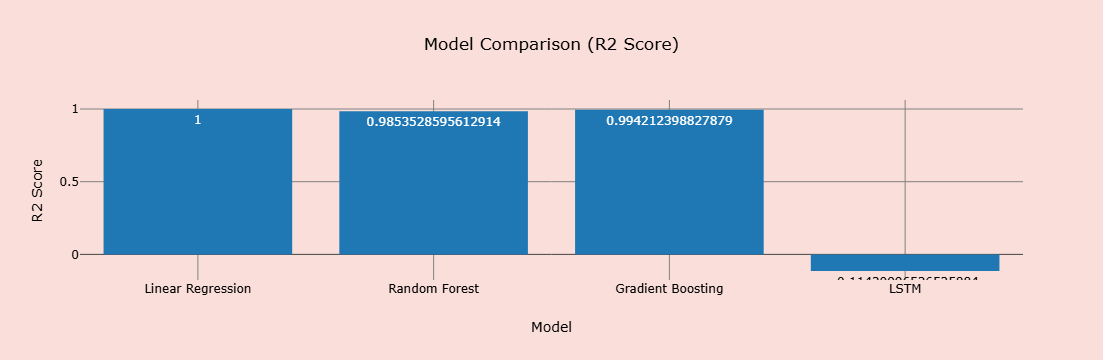

In [59]:
fig = px.bar(
    results_df,
    x='Model',
    y='R2 Score',
    title = 'Model Comparison (R2 Score)',
    text='R2 Score'
)

fig.show()

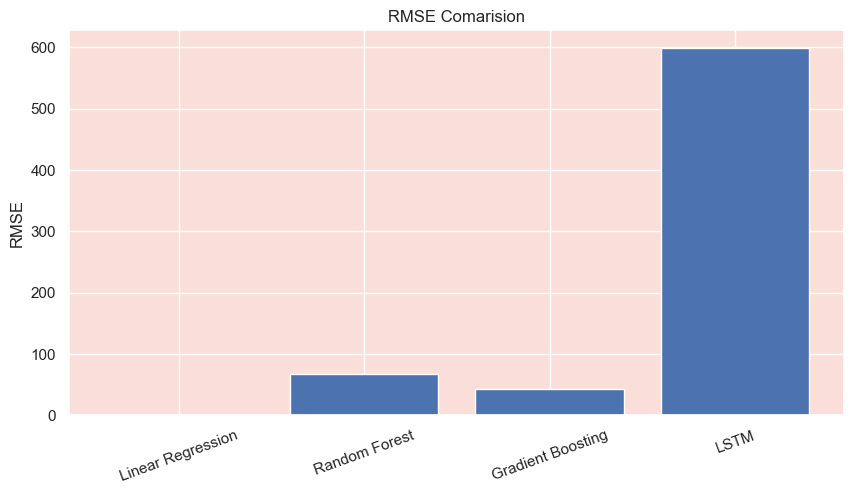

In [60]:
plt.figure(figsize=(10,5))

plt.bar(
    results_df['Model'],
    results_df['RMSE']
)
plt.title('RMSE Comarision')
plt.ylabel('RMSE')
plt.xticks(rotation=20)
plt.show()

<a id="rf"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 12 | Feature Importance(Gradient Boosting  Model) </p>

⬆️ [Table of Contents](#contents_tabel)

In [61]:
importances = gb_model.feature_importances_
features = x.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by = 'Importance', ascending=False)

print(importance_df.head(10))

                Feature  Importance
17         avg_Rainfall    0.942344
15     Monsoon_Rainfall    0.050380
18         Max_Rainfall    0.002638
8                   Aug    0.001488
20         Rainfall_STD    0.001100
11                  Nov    0.000977
26      Previous_2_Year    0.000482
6                  June    0.000228
21  Previous_year_Total    0.000192
7                  July    0.000080


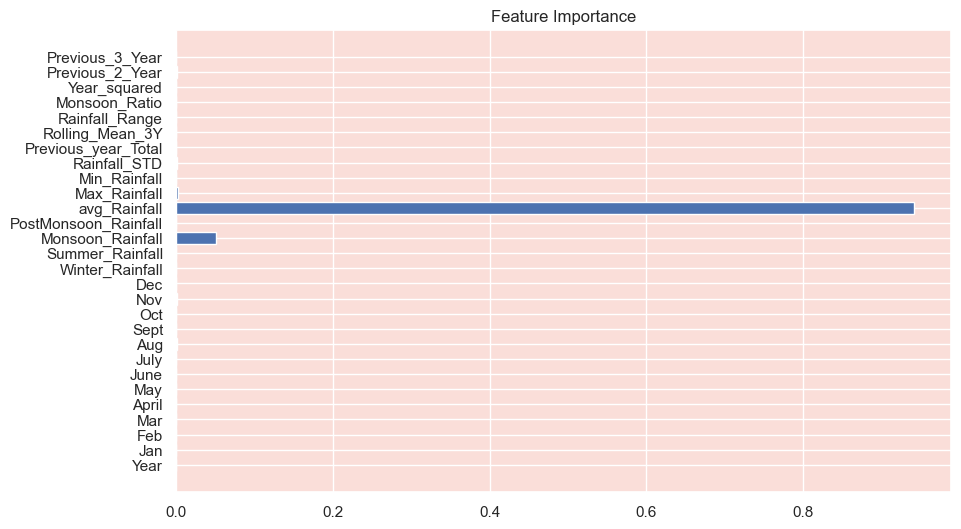

In [62]:
importance = gb_model.feature_importances_

feature_names = x.columns

plt.figure(figsize=(10,6))
plt.barh(feature_names,importance)
plt.title("Feature Importance")
plt.show()

<a id="rf"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 13 | Visualization of prediction </p>

⬆️ [Table of Contents](#contents_tabel)

### Actual vs Predicted

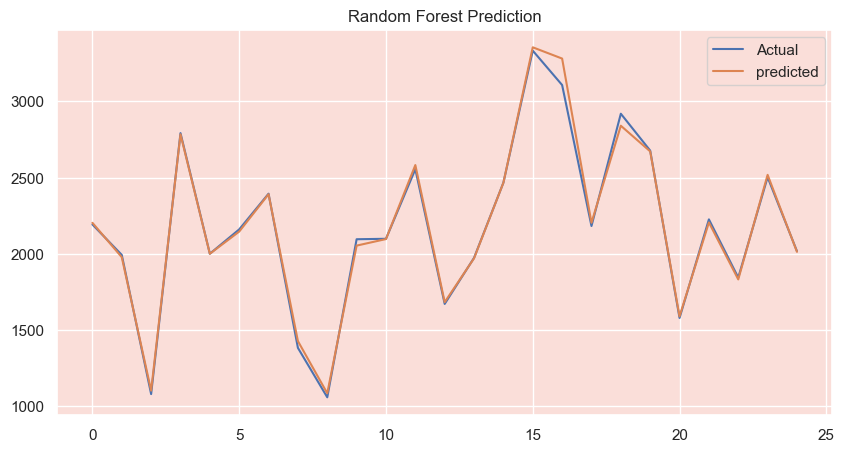

In [63]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    label='Actual'
)
plt.plot(
    gb_pred,
    label='predicted'
)
plt.legend()
plt.title('Random Forest Prediction')
plt.show()

<a id="conclusion"></a>
# <p style="background-color:purple; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 14 | Conclusion</p>

⬆️ [Table of Contents](#contents_tabel)

<div style="border-radius:10px; padding: 15px; background-color: #FFDAB9; font-size:115%; text-align:left">
    
1.Evaluates four models- linear Regression, Random Forest, Gradient Boosting and LSTM - using common error metrics( MAE, MSE, RMSE) and R2- score.
    
2.Based on comprehensive exploratory data analysis(EDA), feature engineering, model training and Evaluation The Gradient Boosting model emerged as 
  the best-performing model for rain forecasting.
  
3.Among all machine learning models tested, the Gradient Boosting Regressor achieved the best performance fall rainfall forecasting with the lowest error
  values(MAE = 2.00, RMSE = 3.48) and a high R2 score (0.99). Therefore, it is selected as the most suitable model for rainfall prediction.
   
4.Unlike other models, Linear Regression model also performed very well but be careful R2 = 1.00 can sometimes indicate overfitting or data leakage.
                       Random Forest performed reasonably well good R2 score(0.98) but higher MAE and RMSE than GB model, so RF is acceptable but not                          the best,
                       The LSTM  model showed poor performance due to limited dataset size. dataset contained only 121 row records, the model could not effectively learn temporal patterns, resulting in a negative R2 Score.
  
5.The Gradient Boosting model should be selected for further tuning or deployment as it consistently provides the most accurate predictions with the least amount of error among the tasted algorithams.